In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines

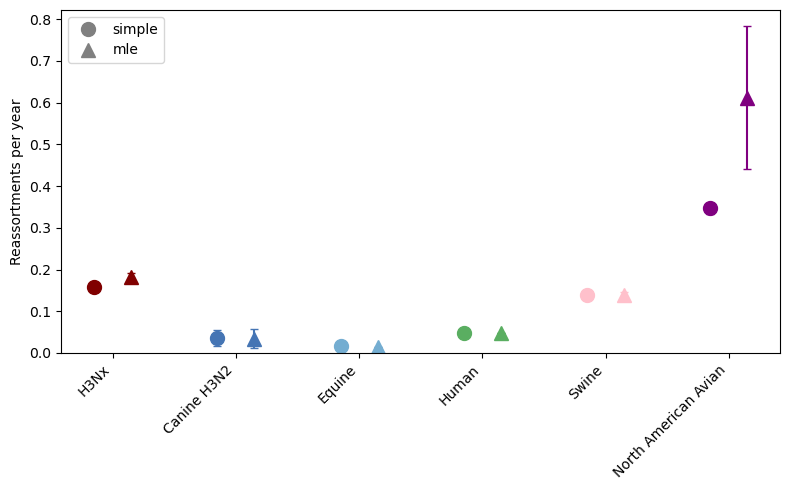

In [2]:
hosts = ["H3Nx", "canine_h3n2", "equine", "human", "swine", "na_avian"]
host_colors = {
    'H3Nx': 'maroon',
    'Equine': '#74add1',
    'Canine H3N2': '#4575b4',
    'Human': '#5aae61',
    'Swine': 'pink',
    'North American Avian': 'purple'
}

results = {}
for host in hosts:
    df = pd.read_csv(f"logs-95/{host}.csv")
    results[host] = {
        "simple_mean": df["simple_rate"].mean(),
        "simple_std": df["simple_rate"].std(),
        "mle_mean": df["mle_rate"].mean(),
        "mle_std": df["mle_rate"].std()
    }
    
# print(results)

stats = pd.DataFrame(results).T

display_names = {
    "H3Nx": "H3Nx",
    "canine_h3n2": "Canine H3N2",
    "equine": "Equine",
    "human": "Human",
    "swine": "Swine",
    "na_avian": "North American Avian"
}

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(hosts))
offset = 0.15  # horizontal shift

for i, host in enumerate(hosts):
    disp_name = display_names[host]
    color = host_colors[disp_name]

    ax.errorbar(
        x[i] - offset, stats.loc[host, "simple_mean"],
        yerr=stats.loc[host, "simple_std"],
        fmt='o', color=color, markersize=10, capsize=3, label="simple" if i == 0 else ""
    )

    ax.errorbar(
        x[i] + offset, stats.loc[host, "mle_mean"],
        yerr=stats.loc[host, "mle_std"],
        fmt='^', color=color, markersize=10, capsize=3, label="mle" if i == 0 else ""
    )
    
    # label is for legend purposes

ax.set_xticks(x)
ax.set_xticklabels([display_names[h] for h in hosts], rotation=45, ha="right")
ax.set_ylabel("Reassortments per year")

circle_handle = mlines.Line2D([], [], color="grey", marker='o', linestyle='None', markersize=10, label='simple')
triangle_handle = mlines.Line2D([], [], color="grey", marker='^', linestyle='None', markersize=10, label='mle')
ax.legend(handles=[circle_handle, triangle_handle])

ax.set_ylim(bottom=0)

plt.tight_layout()

plt.savefig(f"plots/rea_rates.pdf", bbox_inches="tight")
plt.show()


In [11]:
import pandas as pd
from scipy.stats import f_oneway
import glob


files = glob.glob("logs-95/*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source"] = f  # tag file of origin
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# simple rate
groups_simple = [group["simple_rate"] for _, group in data.groupby("source")]
anova_simple = f_oneway(*groups_simple)
print("simple anova", anova_simple)

from scipy.stats import levene
print("simple levene", levene(*groups_simple))

print("\n")

# mle rate
groups_mle = [group["mle_rate"].dropna().values for _, group in data.groupby("source")]
anova_mle = f_oneway(*groups_mle)
print("mle anova", anova_mle)
print("mle levene", levene(*groups_mle))


simple anova F_onewayResult(statistic=156288.46614400955, pvalue=0.0)
simple levene LeveneResult(statistic=176.94814447638848, pvalue=3.629691289379363e-176)


mle anova F_onewayResult(statistic=10172.858308788967, pvalue=0.0)
mle levene LeveneResult(statistic=423.3243161282239, pvalue=0.0)


In [22]:
import pingouin as pg

# welch’s ANOVA simple

welch_simple = pg.welch_anova(dv="simple_rate", between="source", data=data)
print("Welch ANOVA (simple_rate):")
print(welch_simple)

# welch’s ANOVA mle 
welch_mle = pg.welch_anova(dv="mle_rate", between="source", data=data)
print("Welch ANOVA (mle_rate):")
print(welch_mle)

simple anova F_onewayResult(statistic=156288.46614400955, pvalue=0.0)
Welch ANOVA (simple_rate):
   Source  ddof1    ddof2    F  p-unc       np2
0  source      5  2913.75  0.0    1.0  0.992388
Welch ANOVA (mle_rate):
   Source  ddof1    ddof2    F  p-unc      np2
0  source      5  2913.75  0.0    1.0  0.89458


/Users/monclalab1/anaconda3/envs/within-host-prelim-analysis/lib/python3.10/site-packages/pingouin/parametric.py:1346: RuntimeWarning: invalid value encountered in scalar divide
  adj_grandmean = (weights * grp.mean(numeric_only=True)).sum() / weights.sum()
/Users/monclalab1/anaconda3/envs/within-host-prelim-analysis/lib/python3.10/site-packages/pingouin/parametric.py:1346: RuntimeWarning: invalid value encountered in scalar divide
  adj_grandmean = (weights * grp.mean(numeric_only=True)).sum() / weights.sum()


In [27]:
for name, group in data.groupby("source"):
    print(name, group["simple_rate"].mean())

print(data.groupby("source")["simple_rate"].var())


logs-95/H3Nx.csv 0.15740683576763093
logs-95/canine_h3n2.csv 0.036129873356694174
logs-95/equine.csv 0.016054416700888
logs-95/human.csv 0.04809568258837771
logs-95/na_avian.csv 0.34715151503426556
logs-95/swine.csv 0.1382118897737642
source
logs-95/H3Nx.csv           0.000035
logs-95/canine_h3n2.csv    0.000360
logs-95/equine.csv         0.000000
logs-95/human.csv          0.000000
logs-95/na_avian.csv       0.000171
logs-95/swine.csv          0.000019
Name: simple_rate, dtype: float64


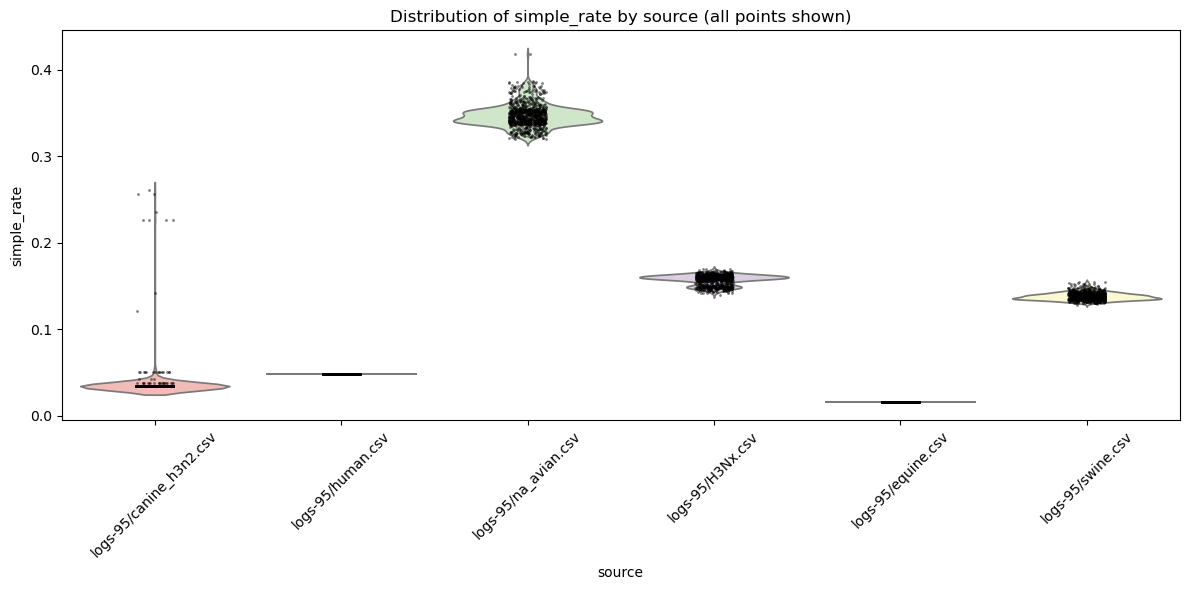

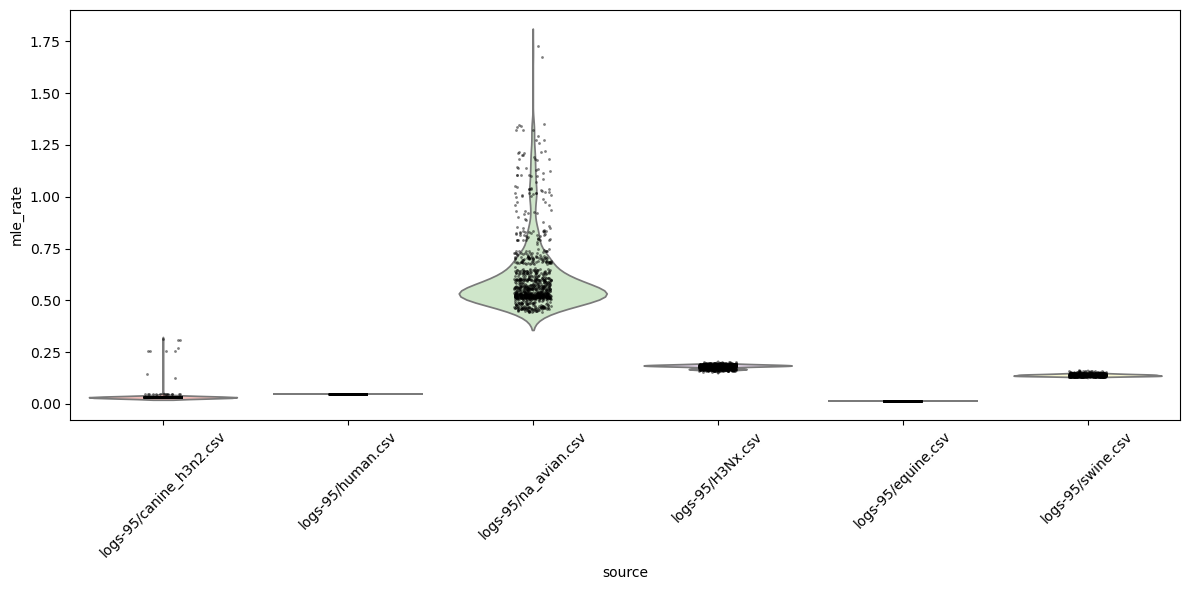

In [21]:
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt

files = glob.glob("logs-95/*.csv")
dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source"] = f
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

plt.figure(figsize=(12, 6))
sns.violinplot(x="source", y="simple_rate", hue="source", data=data, inner=None, palette="Pastel1", dodge=False, legend=False)
sns.stripplot(x="source", y="simple_rate", data=data, color="k", size=2, jitter=True, alpha=0.5)
plt.xticks(rotation=45)
plt.title("Distribution of simple_rate by source (all points shown)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(x="source", y="mle_rate", hue="source", data=data, inner=None, palette="Pastel1", dodge=False, legend=False)
sns.stripplot(x="source", y="mle_rate", data=data, color="k", size=2, jitter=True, alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [28]:
from scipy.stats import kruskal

groups_simple = [group["simple_rate"].values for _, group in data.groupby("source")]
kw = kruskal(*groups_simple)
print("Kruskal-Wallis:", kw)


Kruskal-Wallis: KruskalResult(statistic=5860.4149433055745, pvalue=0.0)
